## Подготовка датасета

Для кластеризации используем только признаки, описывающие пациентов.  
Столбец `ID` удаляется как технический идентификатор.  
Столбец `Status` сохраняется отдельно только для дополнительного сравнения с найденными кластерами.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import metrics

sns.set_palette('husl')
%matplotlib inline

In [ ]:
# Загрузка датасета
df = pd.read_csv('cirrhosis.csv')

print('Размер датасета:', df.shape)
df.head()

Размер датасета: (418, 20)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,418.0,NaN,NaN,NaN,209.5,120.810458,1.0,105.25,209.5,313.75,418.0
N_Days,418.0,NaN,NaN,NaN,1917.782297,1104.672992,41.0,1092.75,1730.0,2613.5,4795.0
Status,418,3,C,232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drug,312,2,D-penicillamine,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,418.0,NaN,NaN,NaN,18533.351675,3815.845055,9598.0,15644.5,18628.0,21272.5,28650.0
Sex,418,2,F,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ascites,312,2,N,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hepatomegaly,312,2,Y,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Spiders,312,2,N,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edema,418,3,N,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Подготовка данных для кластеризации

In [ ]:
# Сохраняем исходный датафрейм
df_clust = df.copy()
status_original = df_clust['Status'].copy()
df_clust = df_clust.drop(columns=['ID'])

#Удаляем пустые значения
df_clust = df_clust.dropna().copy()
df_clust.dropna(subset=['Drug'], inplace=True)

df_clust.Cholesterol = df_clust.Cholesterol.fillna(df_clust.Cholesterol.median())
df_clust.Tryglicerides = df_clust.Tryglicerides.fillna(df_clust.Tryglicerides.median())
df_clust.Copper = df_clust.Copper.fillna(df_clust.Copper.median())
df_clust.Platelets = df_clust.Platelets.fillna(df_clust.Platelets.median())

print('Размер после удаления пропусков:', df_clust.shape)

Размер после удаления пропусков: (276, 19)


In [ ]:
# После удаления пропусков синхронизируем Status
status_original = status_original.loc[df_clust.index]

# Убираем Status из набора для кластеризации
X_raw = df_clust.drop(columns=['Status']).copy()


X = pd.get_dummies(X_raw, drop_first=True)

print('Размер матрицы признаков после кодирования:', X.shape)
X.head()

Размер матрицы признаков после кодирования: (276, 19)


,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Drug_Placebo,Sex_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y
0,400,21464,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,False,False,True,True,True,False,True
1,4500,20617,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,False,False,False,True,True,False,False
2,1012,25594,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,False,True,False,False,False,True,False
3,1925,19994,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,False,False,False,True,True,True,False
4,1504,13918,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,True,False,False,True,True,False,False


## Масштабирование данных

Для алгоритма K-Means масштабирование обязательно, поскольку расстояния между объектами
сильно зависят от масштаба признаков.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Форма масштабированных данных:', X_scaled.shape)

Форма масштабированных данных: (276, 19)


## Подбор числа кластеров

Используем:
- метод локтя (`inertia`)
- коэффициент силуэта (`silhouette score`)

In [ ]:
inertia = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(metrics.silhouette_score(X_scaled, labels))

best_k = k_values[np.argmax(silhouette_scores)]
print('Лучшее количество кластеров по silhouette score:', best_k)

Лучшее количество кластеров по silhouette score: 2


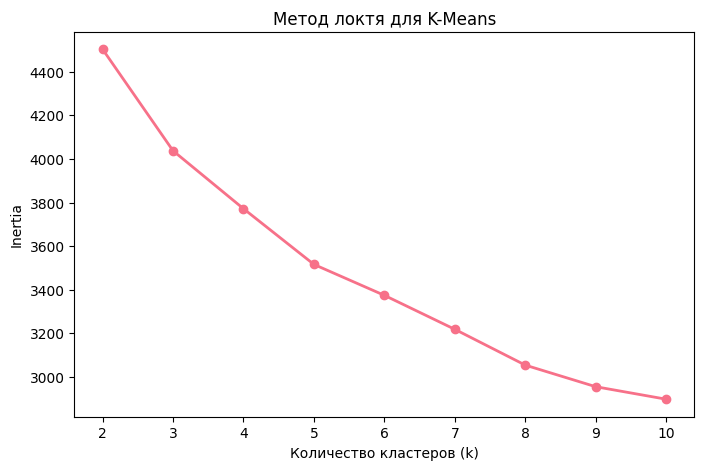

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia, marker='o', linewidth=2)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя для K-Means')
plt.xticks(list(k_values))
plt.show()

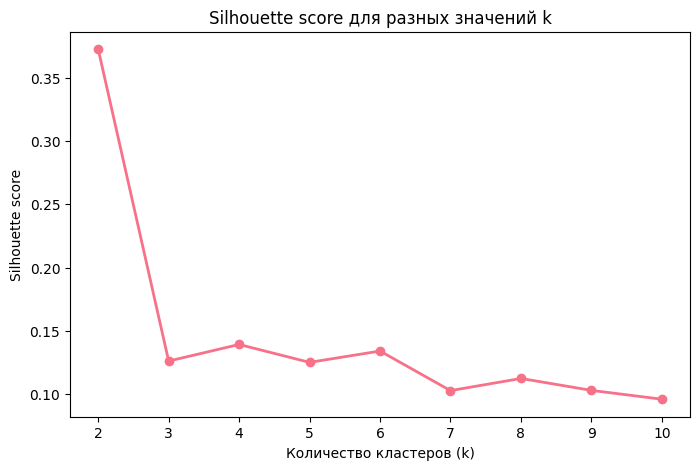

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker='o', linewidth=2)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score для разных значений k')
plt.xticks(list(k_values))
plt.show()

## Обучение итоговой модели K-Means

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print('Silhouette score для итоговой модели:', metrics.silhouette_score(X_scaled, clusters))
print('Inertia итоговой модели:', kmeans.inertia_)

Silhouette score для итоговой модели: 0.3726581536624887
Inertia итоговой модели: 4503.692948269032


In [ ]:
# Добавляем метки кластеров
df_result = df_clust.copy()
df_result['Cluster'] = clusters

df_result[['Status', 'Cluster']].head()

,Status,Cluster
0,D,0
1,C,1
2,D,1
3,D,1
4,CL,1


## Визуализация кластеров с помощью PCA

Поскольку исходное пространство многомерное, уменьшим размерность до двух главных компонент
и визуализируем полученные кластеры на плоскости.

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Объяснённая дисперсия двух компонент:', pca.explained_variance_ratio_)
print('Суммарная объяснённая дисперсия:', pca.explained_variance_ratio_.sum())

Объяснённая дисперсия двух компонент: [0.21991026 0.10742692]
Суммарная объяснённая дисперсия: 0.3273371797623524


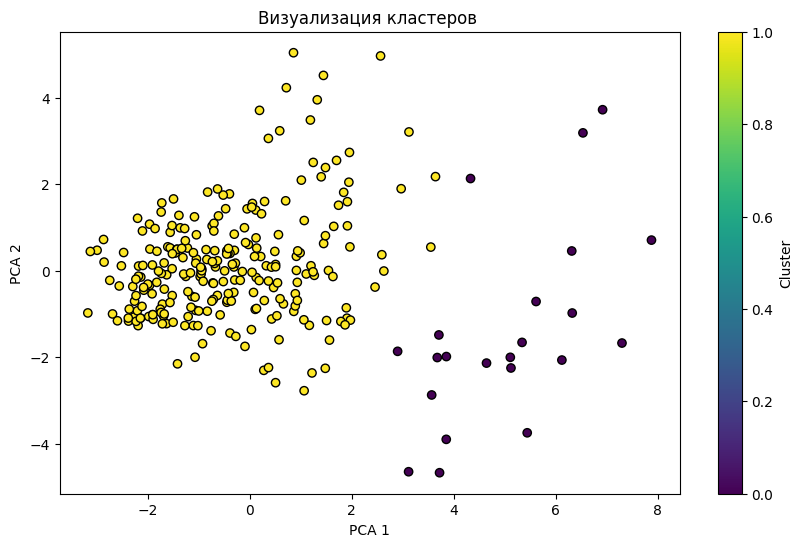

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    edgecolor='k'
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Визуализация кластеров ')
plt.colorbar(scatter, label='Cluster')
plt.show()

## Анализ кластеров

In [ ]:
# Средние значения числовых признаков по кластерам
cluster_profile = df_result.groupby('Cluster').mean(numeric_only=True)
cluster_profile

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
Cluster,,,,,,,,,,,,
0,518.272727,21530.000000,10.904545,330.954545,2.915455,203.772727,2311.072727,156.490000,171.590909,179.590909,12.118182,3.909091
1,2105.700787,17899.976378,2.677953,374.751969,3.568898,91.846457,1969.374803,121.315472,120.940945,268.889764,10.615748,2.964567


In [ ]:
# Размер каждого кластера
df_result['Cluster'].value_counts().sort_index()

,count
Cluster,
0,22
1,254


In [ ]:
# Сравнение найденных кластеров с реальным Status
pd.crosstab(df_result['Status'], df_result['Cluster'])

Cluster,0,1
Status,,
C,2,145
CL,0,18
D,20,91
